In [2]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point, LineString
from scipy.spatial import cKDTree
import warnings
import gtfs_kit as gk
import osmnx as ox
warnings.filterwarnings('ignore')

print("Phase 2: Route Extension & Ranking")
print("="*70)

Phase 2: Route Extension & Ranking


In [3]:
# Cell 2: Load GNN predictions and GTFS data
# Load predictions from Phase 1
predictions_df = pd.read_csv('/home/dataopske/Desktop/jav/data/training_output/all_candidates_equity.csv')
df = pd.read_csv('/home/dataopske/Desktop/jav/data/training_data/stop_features_training_data.csv')
# Load GTFS feed (you already have this)
# load data
print("Loading data...")
# load gtfs data
print("Loading GTFS data...")
feed_path = '/home/dataopske/Desktop/jav/data/raw/digitalmatatu/GTFS_FEED_2019.zip'
feed = gk.read_feed(feed_path, dist_units='km')
gtfs_routes = feed.routes
gtfs_trips = feed.trips
gtfs_stop_times = feed.stop_times
gtfs_stops = feed.stops
gtfs_shapes = feed.shapes
print(f"✓ GTFS loaded: {len(gtfs_routes)} routes, {len(gtfs_stops)} stops")
print(f" Route IDs: {gtfs_routes['route_id'].unique()[:5]}...")

print(f"Loaded {len(predictions_df)} candidate stops")
print(f"\nCandidates by ward category:")
print(predictions_df['ward_category'].value_counts())

# Load existing stops from GTFS
gtfs_stops = feed.stops.copy()
print(f"\nGTFS stops: {len(gtfs_stops)}")

Loading data...
Loading GTFS data...
✓ GTFS loaded: 136 routes, 4284 stops
 Route IDs: <StringArray>
['10000107D11', '10000114011', '10000116011', '10100011A11', '10200010811']
Length: 5, dtype: string...
Loaded 1097 candidate stops

Candidates by ward category:
ward_category
adequately_served       517
underserved             441
severely_underserved    139
Name: count, dtype: int64

GTFS stops: 4284


In [4]:
# Cell 3: Select target wards
# Option A: Manually select wards
# target_wards = [
#     'Mathare North Ward',
#     'Korogocho Ward', 
#     'Sarang\'ombe Ward',
#     'Embakasi Ward',
#     'Airbase Ward'
# ]

# Option B: All underserved/severely underserved
target_wards = predictions_df[
    predictions_df['ward_category'].isin(['underserved', 'severely_underserved'])
]['ward'].unique().tolist()

# Filter candidates
selected_candidates = predictions_df[
    predictions_df['ward'].isin(target_wards)
].copy()

print(f"Selected {len(target_wards)} wards")
print(f"Found {len(selected_candidates)} candidates in these wards\n")

for ward in target_wards:
    ward_cands = selected_candidates[selected_candidates['ward'] == ward]
    print(f"  {ward}: {len(ward_cands)} candidates")

Selected 27 wards
Found 580 candidates in these wards

  Embakasi Ward: 7 candidates
  Airbase Ward: 47 candidates
  Ngando Ward: 31 candidates
  Lucky Summer Ward: 50 candidates
  Njiru Ward: 26 candidates
  Roysambu Ward: 20 candidates
  Pipeline Ward: 18 candidates
  Upper Savanna Ward: 31 candidates
  Matopeni/spring Valley Ward: 24 candidates
  Gatina Ward: 48 candidates
  Dandora Area Iii Ward: 50 candidates
  Mountain View Ward: 29 candidates
  Nairobi West Ward: 33 candidates
  Kangemi Ward: 45 candidates
  Kasarani Ward: 18 candidates
  Karen Ward: 4 candidates
  Karura Ward: 6 candidates
  Imara Daima Ward: 9 candidates
  South C Ward: 9 candidates
  Clay City: 11 candidates
  Uthiru/ruthimitu Ward: 28 candidates
  Waithaka Ward: 12 candidates
  Kitisuru Ward: 7 candidates
  Mwiki Ward: 2 candidates
  Kahawa: 2 candidates
  Githurai Ward: 12 candidates
  Zimmerman Ward: 1 candidates


SNAPPING CANDIDATES TO ROADS
✓ Road network loaded.
Snapping 580 candidates to roads...

 Snapped 580 stops to roads
   Mean snap distance: 159.6m
   Median snap distance: 83.6m
   Max snap distance: 2266.2m

 390 stops snapped >50m away (kept original coords)

Saved visualization to road_snapping_visualization.png


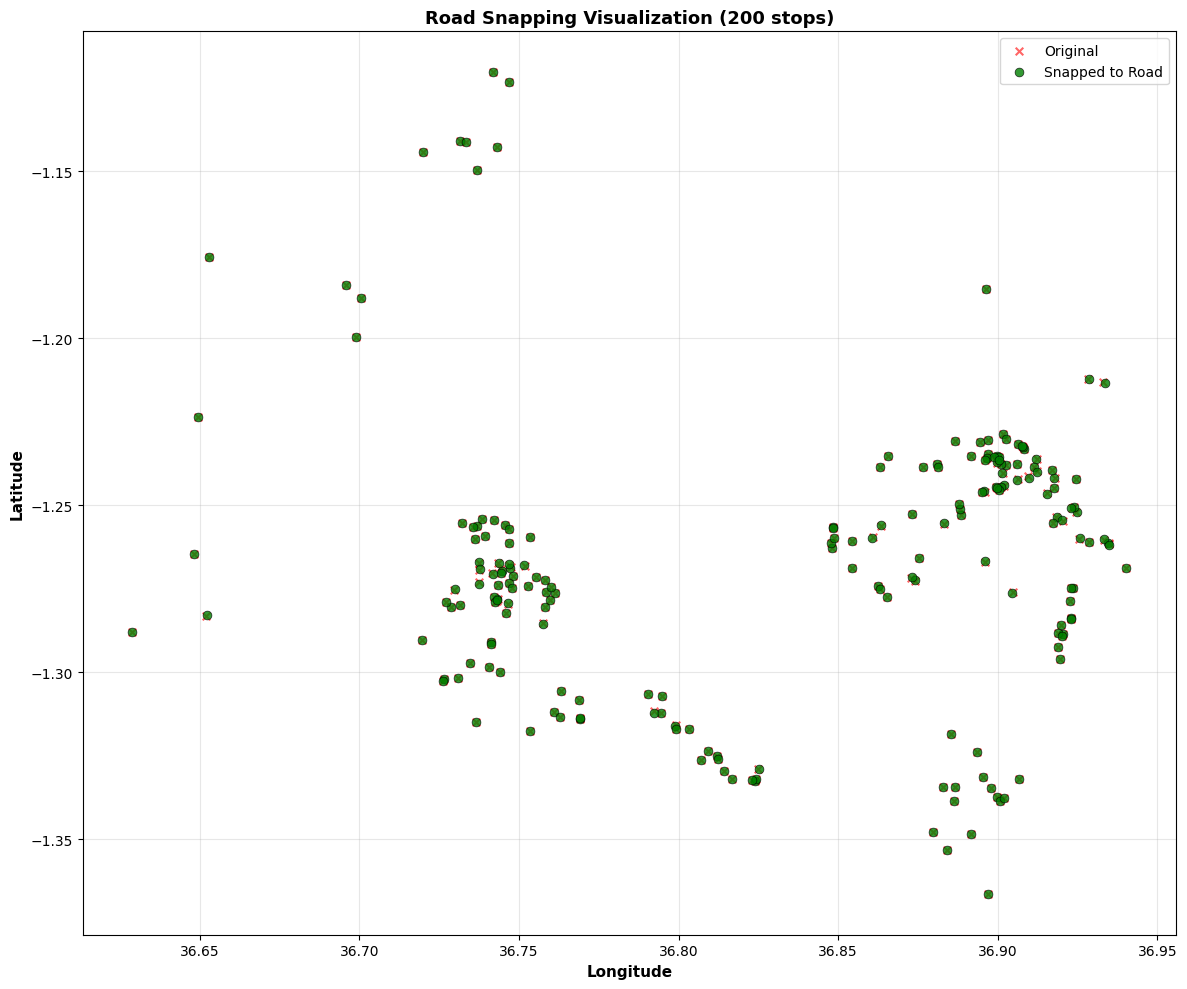

In [5]:
# Cell 5.5: Snap candidate stops to nearest roads
print("="*70)
print("SNAPPING CANDIDATES TO ROADS")
print("="*70)

# load osm road network
print("Downloading road network...")
try:
    G = ox.load_graphml('/home/dataopske/Desktop/jav/data/processed/nairobi_drive.graphml')
except:
    G = ox.graph_from_place("Nairobi, Kenya", network_type='drive')
    ox.save_graphml(G, 'nairobi_roads.graphml')
nodes_gdf = ox.graph_to_gdfs(G, edges=False)
print("✓ Road network loaded.")

def snap_to_nearest_road(lat, lon, G, max_distance=50):
    """Snap a point to nearest road in OSM graph"""
    try:
        # Find nearest node in road network
        nearest_node = ox.distance.nearest_nodes(G, lon, lat)
        node_data = G.nodes[nearest_node]
        
        snapped_lat = node_data['y']
        snapped_lon = node_data['x']
        
        # Calculate snap distance
        from math import radians, sin, cos, sqrt, atan2
        R = 6371000  # Earth radius in meters
        
        lat1, lon1 = radians(lat), radians(lon)
        lat2, lon2 = radians(snapped_lat), radians(snapped_lon)
        
        dlat = lat2 - lat1
        dlon = lon2 - lon1
        
        a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
        c = 2 * atan2(sqrt(a), sqrt(1-a))
        distance = R * c
        
        if distance <= max_distance:
            return snapped_lat, snapped_lon, distance
        else:
            return lat, lon, distance  # Keep original if too far
            
    except Exception as e:
        return lat, lon, None

# Snap all candidates
print(f"Snapping {len(selected_candidates)} candidates to roads...")
snapped_coords = []
snap_distances = []

for idx, row in selected_candidates.iterrows():
    snapped_lat, snapped_lon, distance = snap_to_nearest_road(
        row['lat'], row['lon'], G, max_distance=50
    )
    snapped_coords.append((snapped_lat, snapped_lon))
    snap_distances.append(distance)

# Update coordinates
selected_candidates['lat_original'] = selected_candidates['lat']
selected_candidates['lon_original'] = selected_candidates['lon']
selected_candidates['lat'] = [coord[0] for coord in snapped_coords]
selected_candidates['lon'] = [coord[1] for coord in snapped_coords]
selected_candidates['snap_distance'] = snap_distances

print(f"\n Snapped {len(selected_candidates)} stops to roads")
valid_distances = [d for d in snap_distances if d is not None]
print(f"   Mean snap distance: {np.mean(valid_distances):.1f}m")
print(f"   Median snap distance: {np.median(valid_distances):.1f}m")
print(f"   Max snap distance: {np.max(valid_distances):.1f}m")

# Check for poorly snapped stops
poorly_snapped = selected_candidates[
    (selected_candidates['snap_distance'].notna()) & 
    (selected_candidates['snap_distance'] > 50)
]
if len(poorly_snapped) > 0:
    print(f"\n {len(poorly_snapped)} stops snapped >50m away (kept original coords)")

# Visualize snapping
fig, ax = plt.subplots(figsize=(12, 10))

# Sample for visualization
sample_size = min(200, len(selected_candidates))
sample = selected_candidates.sample(sample_size)

# Original positions
ax.scatter(sample['lon_original'], sample['lat_original'], 
          c='red', s=30, alpha=0.6, label='Original', marker='x', zorder=3)

# Snapped positions
ax.scatter(sample['lon'], sample['lat'], 
          c='green', s=40, alpha=0.8, label='Snapped to Road', marker='o', 
          edgecolors='black', linewidth=0.5, zorder=4)

# Draw snap lines
for idx, row in sample.iterrows():
    if row['snap_distance'] is not None and row['snap_distance'] < 50:
        ax.plot([row['lon_original'], row['lon']], 
               [row['lat_original'], row['lat']], 
               'gray', alpha=0.2, linewidth=0.8, zorder=2)

ax.set_xlabel('Longitude', fontweight='bold', fontsize=11)
ax.set_ylabel('Latitude', fontweight='bold', fontsize=11)
ax.set_title(f'Road Snapping Visualization ({sample_size} stops)', 
            fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('road_snapping_visualization.png', dpi=300, bbox_inches='tight')
print("\nSaved visualization to road_snapping_visualization.png")
plt.show()

print("\n" + "="*70)

In [6]:
# Cell 4: Get routes serving these wards
# Join stops with stop_times to get routes
stop_times = feed.stop_times.copy()
routes = feed.routes.copy()
trips = feed.trips.copy()

# Get stops in target wards (from your main df with ward info)
ward_stops = df[df['ward'].isin(target_wards)]['stop_id'].unique()

# Find which routes serve these wards
routes_in_wards = stop_times[
    stop_times['stop_id'].isin(ward_stops)
].merge(trips[['trip_id', 'route_id']], on='trip_id')['route_id'].unique()

print(f"Found {len(routes_in_wards)} routes serving target wards")

# Get route details
ward_routes = routes[routes['route_id'].isin(routes_in_wards)].copy()
print(f"\nRoutes in target wards:")
print(ward_routes[['route_id', 'route_short_name', 'route_long_name']].head(10))

Found 106 routes serving target wards

Routes in target wards:
       route_id route_short_name                      route_long_name
0   10000107D11             107D                          Ruaka-Ruiru
1   10000114011             114R          Ngara-Rwaka-Ndenderu-Limuru
2   10000116011              116             Koja-Ngara-Banana-Limuru
3   10100011A11              11A             Odeon-Aga Khan-Highridge
4   10200010811              108       UN-New Muthaiga-Gachie-Gichagi
5   10300011F11              11B                       Odeon-UN-Ruaka
6   10300106011              106                 Koja-UN-Ruaka-Banana
7   10400010711              107              Odeon-UN-Ruaka-Ndenderu
9   20000004511              45K    Odeon-Pangani-Roysabu-Githurai-KU
10  20000004512              45G  Munyu Road-Pangani-Roysabu-Githurai


In [7]:
# Cell 5: Build route geometries (ordered stop sequences)
def get_route_stops_ordered(route_id, feed):
    """Get ordered stops for a route"""
    # Get all trips for this route
    route_trips = feed.trips[feed.trips['route_id'] == route_id]['trip_id'].head(1).values
    
    if len(route_trips) == 0:
        return None
    
    # Get stop sequence for first trip (representative)
    trip_stops = feed.stop_times[
        feed.stop_times['trip_id'] == route_trips[0]
    ].sort_values('stop_sequence')
    
    # Merge with stop coordinates
    trip_stops = trip_stops.merge(
        feed.stops[['stop_id', 'stop_lat', 'stop_lon']], 
        on='stop_id'
    )
    
    return trip_stops[['stop_id', 'stop_sequence', 'stop_lat', 'stop_lon']]

# Build route geometries
route_geometries = {}

for route_id in routes_in_wards:
    stops = get_route_stops_ordered(route_id, feed)
    if stops is not None and len(stops) > 1:
        route_geometries[route_id] = stops

print(f"Built geometries for {len(route_geometries)} routes")
print(f"\nSample route stops:")
sample_route = list(route_geometries.keys())[0]
print(route_geometries[sample_route].head())

Built geometries for 106 routes

Sample route stops:
   stop_id  stop_sequence  stop_lat   stop_lon
0  0110BAA              1 -1.174235  36.758765
1  0110BNI              2 -1.174564  36.758993
2  0110UMK              3 -1.175079  36.759251
3  0110AEA              4 -1.175848  36.759530
4  0100MOM              5 -1.177860  36.760345


In [8]:
# Cell 6: Match candidates to routes (spatial proximity)
def find_candidates_near_route(route_stops, candidates_df, buffer_meters=500):
    """Find candidate stops within buffer of route"""
    # Route coordinates
    route_coords = route_stops[['stop_lat', 'stop_lon']].values
    route_tree = cKDTree(route_coords)
    
    # Candidate coordinates
    cand_coords = candidates_df[['lat', 'lon']].values
    
    # Find candidates within buffer (approx degrees)
    buffer_degrees = buffer_meters / 111000  # rough conversion
    
    matches = []
    for i, (lat, lon) in enumerate(cand_coords):
        distances, indices = route_tree.query([lat, lon], k=1)
        
        if distances < buffer_degrees:
            # Find best insertion point (between which stops)
            nearest_stop_idx = indices
            
            matches.append({
                'candidate_idx': i,
                'candidate_id': candidates_df.iloc[i]['stop_id'],
                'nearest_route_stop_idx': nearest_stop_idx,
                'distance_meters': distances * 111000
            })
    
    return pd.DataFrame(matches)

# Match candidates to each route
route_candidate_matches = {}

for route_id, route_stops in route_geometries.items():
    matches = find_candidates_near_route(route_stops, selected_candidates, buffer_meters=500)
    
    if len(matches) > 0:
        route_candidate_matches[route_id] = matches

print(f"Matched candidates to {len(route_candidate_matches)} routes")
print(f"\nSample matches for route {list(route_candidate_matches.keys())[0]}:")
print(route_candidate_matches[list(route_candidate_matches.keys())[0]].head())

Matched candidates to 74 routes

Sample matches for route 20801002511:
   candidate_idx                   candidate_id  nearest_route_stop_idx  \
0              2      CANDIDATE_Airbase Ward_31                       9   
1             14  CANDIDATE_Lucky Summer Ward_2                       0   
2             39     CANDIDATE_Roysambu Ward_24                      14   
3             48       CANDIDATE_Airbase Ward_9                      14   
4             49      CANDIDATE_Airbase Ward_13                      14   

   distance_meters  
0       460.882734  
1       495.890018  
2       464.772338  
3       483.921063  
4       408.610228  


In [23]:
# Cell 7: Generate route variants
def generate_route_variants(route_id, route_stops, matches, candidates_df, max_variants=5):
    """Generate route variants by adding 1-3 new stops"""
    variants = []
    
    # Get matched candidates sorted by quality
    matched_cands = matches.merge(
        candidates_df.reset_index(),
        left_on='candidate_idx',
        right_index=True
    ).sort_values('gnn_probability', ascending=False)
    
    if len(matched_cands) == 0:
        return []
    
    # Variant 1: Add top 1 candidate
    if len(matched_cands) >= 1:
        variants.append({
            'route_id': route_id,
            'variant_id': f"{route_id}_A",
            'new_stops': [matched_cands.iloc[0]['candidate_id']],
            'new_stop_coords': [(matched_cands.iloc[0]['lat'], matched_cands.iloc[0]['lon'])],
            'quality_scores': [matched_cands.iloc[0]['gnn_probability']],
            'pop_served': [matched_cands.iloc[0]['pop_within_500m']]
        })
    
    # Variant 2: Add top 2 candidates
    if len(matched_cands) >= 2:
        variants.append({
            'route_id': route_id,
            'variant_id': f"{route_id}_B",
            'new_stops': matched_cands.iloc[:2]['candidate_id'].tolist(),
            'new_stop_coords': list(zip(matched_cands.iloc[:2]['lat'], matched_cands.iloc[:2]['lon'])),
            'quality_scores': matched_cands.iloc[:2]['gnn_probability'].tolist(),
            'pop_served': matched_cands.iloc[:2]['pop_within_500m'].tolist()
        })
    
    # Variant 3: Add top 3 candidates
    if len(matched_cands) >= 3:
        variants.append({
            'route_id': route_id,
            'variant_id': f"{route_id}_C",
            'new_stops': matched_cands.iloc[:3]['candidate_id'].tolist(),
            'new_stop_coords': list(zip(matched_cands.iloc[:3]['lat'], matched_cands.iloc[:3]['lon'])),
            'quality_scores': matched_cands.iloc[:3]['gnn_probability'].tolist(),
            'pop_served': matched_cands.iloc[:3]['pop_within_500m'].tolist()
        })
    
    return variants[:max_variants]

# Generate variants for all routes
all_variants = []

for route_id, matches in route_candidate_matches.items():
    if route_id in route_geometries:
        variants = generate_route_variants(
            route_id, 
            route_geometries[route_id], 
            matches, 
            selected_candidates,
            max_variants=3
        )
        all_variants.extend(variants)

variants_df = pd.DataFrame(all_variants)
print(f"Generated {len(variants_df)} route variants")
print(f"\nSample variants:")
print(variants_df.head())

Generated 200 route variants

Sample variants:
      route_id     variant_id  \
0  20801002511  20801002511_A   
1  20801002511  20801002511_B   
2  20801002511  20801002511_C   
3  20101007700  20101007700_A   
4  20101007700  20101007700_B   

                                           new_stops  \
0                        [CANDIDATE_Airbase Ward_31]   
1  [CANDIDATE_Airbase Ward_31, CANDIDATE_Lucky Su...   
2  [CANDIDATE_Airbase Ward_31, CANDIDATE_Lucky Su...   
3                        [CANDIDATE_Airbase Ward_31]   
4  [CANDIDATE_Airbase Ward_31, CANDIDATE_Airbase ...   

                                     new_stop_coords  \
0                         [(-1.2516177, 36.8720704)]   
1  [(-1.2516177, 36.8720704), (-1.248364205928465...   
2  [(-1.2516177, 36.8720704), (-1.248364205928465...   
3                         [(-1.2516177, 36.8720704)]   
4  [(-1.2516177, 36.8720704), (-1.256635856941943...   

                      quality_scores            pop_served  
0                  

In [24]:
# Cell 8 (REPLACE): Score route variants
def score_route_variant(variant, weight_coverage=0.50, weight_equity=0.20, 
                       weight_speed=0.15, weight_congestion=0.15):
    """Score a route variant"""
    
    # Coverage score: total new population served
    total_pop = sum(variant['pop_served'])
    coverage_score = total_pop / 150000  # normalize (max ~150k)
    coverage_score = min(coverage_score, 1.0)
    
    # Equity score: check ward categories of new stops
    new_stop_ids = variant['new_stops']
    ward_cats = []
    
    for sid in new_stop_ids:
        match = selected_candidates[selected_candidates['stop_id'] == sid]
        if len(match) > 0:
            ward_cats.append(match['ward_category'].values[0])
    
    # Equity multiplier
    equity_multipliers = {
        'severely_underserved': 2.0,
        'underserved': 1.5,
        'adequately_served': 1.0,
        'well_served': 0.8
    }
    
    avg_multiplier = np.mean([equity_multipliers.get(cat, 1.0) for cat in ward_cats]) if ward_cats else 1.0
    equity_score = avg_multiplier / 2.0  # normalize to 0-1
    
    # Speed score: use existing route average (placeholder)
    speed_score = 0.5  # placeholder - you can enhance this later
    
    # Congestion score: 1 - (congestion_pct / 100)
    congestion_score = 0.6  # placeholder - you can enhance this later
    
    # Final score
    final_score = (
        weight_coverage * coverage_score * avg_multiplier +  # Coverage with equity boost
        weight_equity * equity_score +
        weight_speed * speed_score +
        weight_congestion * congestion_score
    )
    
    return {
        'coverage_score': coverage_score,
        'equity_score': equity_score,
        'equity_multiplier': avg_multiplier,
        'speed_score': speed_score,
        'congestion_score': congestion_score,
        'final_score': final_score,
        'total_pop_served': total_pop
    }

# Score all variants
scores = []
for idx, variant in variants_df.iterrows():
    score = score_route_variant(variant)  # Removed df argument
    scores.append(score)

scores_df = pd.DataFrame(scores)
variants_df = pd.concat([variants_df, scores_df], axis=1)

print("Scored all variants")
print(f"\nScore statistics:")
print(variants_df[['final_score', 'total_pop_served', 'equity_multiplier']].describe())

Scored all variants

Score statistics:
       final_score  total_pop_served  equity_multiplier
count   200.000000        200.000000         200.000000
mean      0.505394      31473.700000           1.665000
std       0.121749      22176.050962           0.208012
min       0.334325       3865.000000           1.500000
25%       0.432785      16457.000000           1.500000
50%       0.474713      26369.000000           1.500000
75%       0.573094      38248.500000           1.833333
max       1.010865     139173.000000           2.000000


In [25]:
# Cell 8A: Aggregate route-level temporal & performance metrics
print("="*70)
print("AGGREGATING ROUTE-LEVEL METRICS")
print("="*70)

def get_route_metrics(route_id, route_stops, df):
    """Aggregate temporal and performance metrics for a route"""
    
    # Get stop IDs for this route
    stop_ids = route_stops['stop_id'].values
    
    # Filter main df for these stops
    route_stop_data = df[df['stop_id'].isin(stop_ids)]
    
    if len(route_stop_data) == 0:
        return None
    
    # Aggregate metrics (weighted by population)
    total_pop = route_stop_data['pop_within_500m'].sum()
    
    if total_pop == 0:
        return None
    
    # Temporal metrics
    trips_per_hour = route_stop_data['trips_per_1k_pop_per_hour'].mean()
    trips_per_day = route_stop_data['trips_per_day'].sum()
    avg_headway = route_stop_data['avg_headway_minutes'].mean()
    service_span = route_stop_data['service_span_hours'].mean()
    
    # Performance metrics (population-weighted)
    weights = route_stop_data['pop_within_500m'] / total_pop
    
    avg_speed = (route_stop_data['avg_speed_daily'] * weights).sum()
    avg_speed_peak = (route_stop_data['avg_speed_peak'] * weights).sum()
    congestion_pct = (route_stop_data['congestion_pct_daily'] * weights).sum()
    congestion_peak = (route_stop_data['congestion_pct_peak'] * weights).sum()
    
    # Demand metrics (from traffic model)
    trip_count_daily = route_stop_data['trip_count_daily'].sum()
    trip_count_peak = route_stop_data['trip_count_peak'].sum()
    demand_variability = route_stop_data['demand_variability_cv'].mean()
    
    return {
        'route_id': route_id,
        'total_pop_served': total_pop,
        'num_stops': len(route_stop_data),
        
        # Temporal
        'trips_per_1k_pop_per_hour': trips_per_hour,
        'trips_per_day': trips_per_day,
        'avg_headway_minutes': avg_headway,
        'service_span_hours': service_span,
        
        # Performance
        'avg_speed_daily': avg_speed,
        'avg_speed_peak': avg_speed_peak,
        'congestion_pct_daily': congestion_pct,
        'congestion_pct_peak': congestion_peak,
        
        # Demand
        'trip_count_daily': trip_count_daily,
        'trip_count_peak': trip_count_peak,
        'demand_variability_cv': demand_variability
    }

# Aggregate for all routes
route_metrics_list = []

for route_id, route_stops in route_geometries.items():
    metrics = get_route_metrics(route_id, route_stops, df)
    if metrics:
        route_metrics_list.append(metrics)

route_metrics_df = pd.DataFrame(route_metrics_list)

print(f"\nAggregated metrics for {len(route_metrics_df)} routes")
print("\nSample route metrics:")
print(route_metrics_df.head())

print("\nMetric statistics:")
print(route_metrics_df[['trips_per_1k_pop_per_hour', 'avg_speed_daily', 
                        'congestion_pct_daily', 'trip_count_daily']].describe())

AGGREGATING ROUTE-LEVEL METRICS

Aggregated metrics for 103 routes

Sample route metrics:
      route_id  total_pop_served  num_stops  trips_per_1k_pop_per_hour  \
0  10300106011            112831         50                  32.100019   
1  10400010711            104718         50                  31.719988   
2  10200010811             26512         19                  21.680604   
3  10000114011             75115         70                  22.498293   
4  10000116011             55820         43                  26.150801   

   trips_per_day  avg_headway_minutes  service_span_hours  avg_speed_daily  \
0            158           760.783377            0.280000        17.811246   
1            164           770.102857            0.320000        17.808879   
2             20          1402.105263            0.000000        18.046455   
3            140          1072.000000            0.228571        17.863141   
4            122           744.372093            0.325581        17.869854 

In [12]:
# Cell 8B: Calculate comprehensive scores for route variants
from sklearn.preprocessing import MinMaxScaler

print("="*70)
print("CALCULATING COMPREHENSIVE SCORES")
print("="*70)

# Normalize route-level metrics (0-1 scale)
scaler = MinMaxScaler()

normalized_metrics = route_metrics_df.copy()
metrics_to_normalize = [
    'trips_per_1k_pop_per_hour',
    'avg_speed_daily',
    'congestion_pct_daily',
    'trip_count_daily'
]

normalized_metrics[metrics_to_normalize] = scaler.fit_transform(
    route_metrics_df[metrics_to_normalize]
)

# Create lookup dictionary
route_metrics_dict = normalized_metrics.set_index('route_id').to_dict('index')

def score_variant_comprehensive(variant, selected_candidates, route_metrics_dict, df):
    """
    Comprehensive scoring with spatial + temporal + performance + demand
    
    Weights:
    - Coverage (spatial): 30%
    - Temporal equity: 25%
    - Performance (speed): 20%
    - Demand matching: 15%
    - Equity boost: 10%
    """
    
    # === 1. SPATIAL COVERAGE SCORE ===
    total_pop = sum(variant['pop_served'])
    coverage_score = min(total_pop / 150000, 1.0)  # Normalize to max 150k
    
    # === 2. EQUITY MULTIPLIER ===
    new_stop_ids = variant['new_stops']
    ward_cats = []
    
    for sid in new_stop_ids:
        match = selected_candidates[selected_candidates['stop_id'] == sid]
        if len(match) > 0:
            ward_cats.append(match['ward_category'].values[0])
    
    equity_multipliers = {
        'severely_underserved': 2.0,
        'underserved': 1.5,
        'adequately_served': 1.0,
        'well_served': 0.8
    }
    
    avg_equity_mult = np.mean([equity_multipliers.get(cat, 1.0) for cat in ward_cats]) if ward_cats else 1.0
    
    # === 3. TEMPORAL EQUITY SCORE ===
    # Get baseline route temporal metrics
    route_id = variant['route_id']
    base_metrics = route_metrics_dict.get(route_id, {})
    
    # Current temporal service level (normalized 0-1)
    current_temporal = base_metrics.get('trips_per_1k_pop_per_hour', 0.5)
    
    # Calculate new stops' temporal potential
    new_stop_temporal = []
    for sid in new_stop_ids:
        stop_data = df[df['stop_id'] == sid]
        if len(stop_data) > 0:
            # New stops inherit route's service frequency
            # Score by how underserved the area is
            stop_trips = stop_data.iloc[0].get('trips_per_1k_pop_per_hour', 0)
            # Invert: lower current service = higher score
            temporal_need = 1.0 - min(stop_trips / 10.0, 1.0)  # Normalize to max 10
            new_stop_temporal.append(temporal_need)
    
    # Temporal equity score: prioritize adding stops to low-service areas
    if new_stop_temporal:
        temporal_equity_score = np.mean(new_stop_temporal)
    else:
        temporal_equity_score = 0.5
    
    # === 4. PERFORMANCE SCORE (Speed + Congestion) ===
    # Get route performance
    avg_speed_norm = base_metrics.get('avg_speed_daily', 0.5)
    congestion_norm = base_metrics.get('congestion_pct_daily', 0.5)
    
    # Speed score: higher is better
    speed_score = avg_speed_norm
    
    # Congestion score: lower congestion is better
    congestion_score = 1.0 - congestion_norm
    
    # Combined performance: 60% speed, 40% congestion
    performance_score = 0.6 * speed_score + 0.4 * congestion_score
    
    # === 5. DEMAND MATCHING SCORE ===
    # How well does the route serve actual demand?
    trip_count_norm = base_metrics.get('trip_count_daily', 0.5)
    
    # Calculate demand potential of new stops
    new_stop_demand = []
    for sid in new_stop_ids:
        stop_data = df[df['stop_id'] == sid]
        if len(stop_data) > 0:
            stop_trips = stop_data.iloc[0].get('trip_count_daily', 0)
            # Normalize (typical max ~5000 trips)
            demand_norm = min(stop_trips / 5000.0, 1.0)
            new_stop_demand.append(demand_norm)
    
    if new_stop_demand:
        new_demand_score = np.mean(new_stop_demand)
    else:
        new_demand_score = 0.5
    
    # Combine: 50% existing route demand, 50% new stop potential
    demand_match_score = 0.5 * trip_count_norm + 0.5 * new_demand_score
    
    # === 6. FINAL SCORE ===
    final_score = (
        0.30 * coverage_score * avg_equity_mult +  # Spatial coverage with equity boost
        0.25 * temporal_equity_score +              # Temporal equity (serve underserved times)
        0.20 * performance_score +                  # Speed + low congestion
        0.15 * demand_match_score +                 # Match actual demand
        0.10 * (avg_equity_mult / 2.0)             # Additional equity weight
    )
    
    return {
        'coverage_score': coverage_score,
        'temporal_equity_score': temporal_equity_score,
        'performance_score': performance_score,
        'speed_score': speed_score,
        'congestion_score': congestion_score,
        'demand_match_score': demand_match_score,
        'equity_multiplier': avg_equity_mult,
        'final_score': final_score,
        'total_pop_served': total_pop
    }

# Re-score all variants with comprehensive scoring
print("Scoring variants with spatial + temporal + performance + demand...")

comprehensive_scores = []
for idx, variant in variants_df.iterrows():
    score = score_variant_comprehensive(
        variant, 
        selected_candidates, 
        route_metrics_dict,
        df
    )
    comprehensive_scores.append(score)

# Replace old scores
scores_df = pd.DataFrame(comprehensive_scores)
variants_df = variants_df.drop(columns=[col for col in variants_df.columns if col in scores_df.columns])
variants_df = pd.concat([variants_df, scores_df], axis=1)

print("\nComprehensive scoring complete!")
print("\nScore component statistics:")
print(variants_df[['coverage_score', 'temporal_equity_score', 'performance_score', 
                  'demand_match_score', 'final_score']].describe())

CALCULATING COMPREHENSIVE SCORES
Scoring variants with spatial + temporal + performance + demand...



Comprehensive scoring complete!

Score component statistics:
       coverage_score  temporal_equity_score  performance_score  \
count      200.000000             200.000000         200.000000   
mean         0.209825               0.189941           0.423878   
std          0.147840               0.271460           0.115177   
min          0.025767               0.000000           0.223305   
25%          0.109713               0.000000           0.363124   
50%          0.175793               0.000000           0.402777   
75%          0.254990               0.370721           0.441055   
max          0.927820               0.862896           0.904379   

       demand_match_score  final_score  
count          200.000000   200.000000  
mean             0.205004     0.350598  
std              0.096031     0.116801  
min              0.025100     0.174313  
25%              0.136577     0.273314  
50%              0.185068     0.329639  
75%              0.258961     0.410539  
max   

In [13]:
# Cell 8C: Re-rank with new comprehensive scores
variants_df = variants_df.sort_values('final_score', ascending=False)

print("="*70)
print("TOP 20 ROUTES - COMPREHENSIVE RANKING")
print("="*70)
print("Spatial (30%) + Temporal (25%) + Performance (20%) + Demand (15%) + Equity (10%)")
print("="*70)

top_20 = variants_df.head(20)

for i, (idx, row) in enumerate(top_20.iterrows(), 1):
    print(f"\n{i}. {row['variant_id']}")
    print(f"   Final Score: {row['final_score']:.3f}")
    print(f"   - Coverage: {row['coverage_score']:.3f} (pop: {row['total_pop_served']:,.0f})")
    print(f"   - Temporal Equity: {row['temporal_equity_score']:.3f}")
    print(f"   - Performance: {row['performance_score']:.3f} (speed: {row['speed_score']:.3f}, congestion: {row['congestion_score']:.3f})")
    print(f"   - Demand Match: {row['demand_match_score']:.3f}")
    print(f"   - Equity Boost: {row['equity_multiplier']:.2f}x")

# Save comprehensive recommendations
variants_df.to_csv('route_recommendations_comprehensive.csv', index=False)
print(f"\n\nSaved {len(variants_df)} comprehensive recommendations")

TOP 20 ROUTES - COMPREHENSIVE RANKING
Spatial (30%) + Temporal (25%) + Performance (20%) + Demand (15%) + Equity (10%)

1. 30603373812_C
   Final Score: 0.757
   - Coverage: 0.928 (pop: 139,173)
   - Temporal Equity: 0.576
   - Performance: 0.430 (speed: 0.354, congestion: 0.544)
   - Demand Match: 0.230
   - Equity Boost: 1.50x

2. 20000004513_C
   Final Score: 0.743
   - Coverage: 0.532 (pop: 79,743)
   - Temporal Equity: 0.863
   - Performance: 0.520 (speed: 0.418, congestion: 0.674)
   - Demand Match: 0.025
   - Equity Boost: 2.00x

3. 80500010511_C
   Final Score: 0.688
   - Coverage: 0.741 (pop: 111,183)
   - Temporal Equity: 0.709
   - Performance: 0.324 (speed: 0.293, congestion: 0.371)
   - Demand Match: 0.248
   - Equity Boost: 1.50x

4. 40601003611_C
   Final Score: 0.680
   - Coverage: 0.728 (pop: 109,239)
   - Temporal Equity: 0.384
   - Performance: 0.441 (speed: 0.377, congestion: 0.538)
   - Demand Match: 0.322
   - Equity Boost: 1.67x

5. 20000004513_B
   Final Score: 


Saved comprehensive scoring analysis


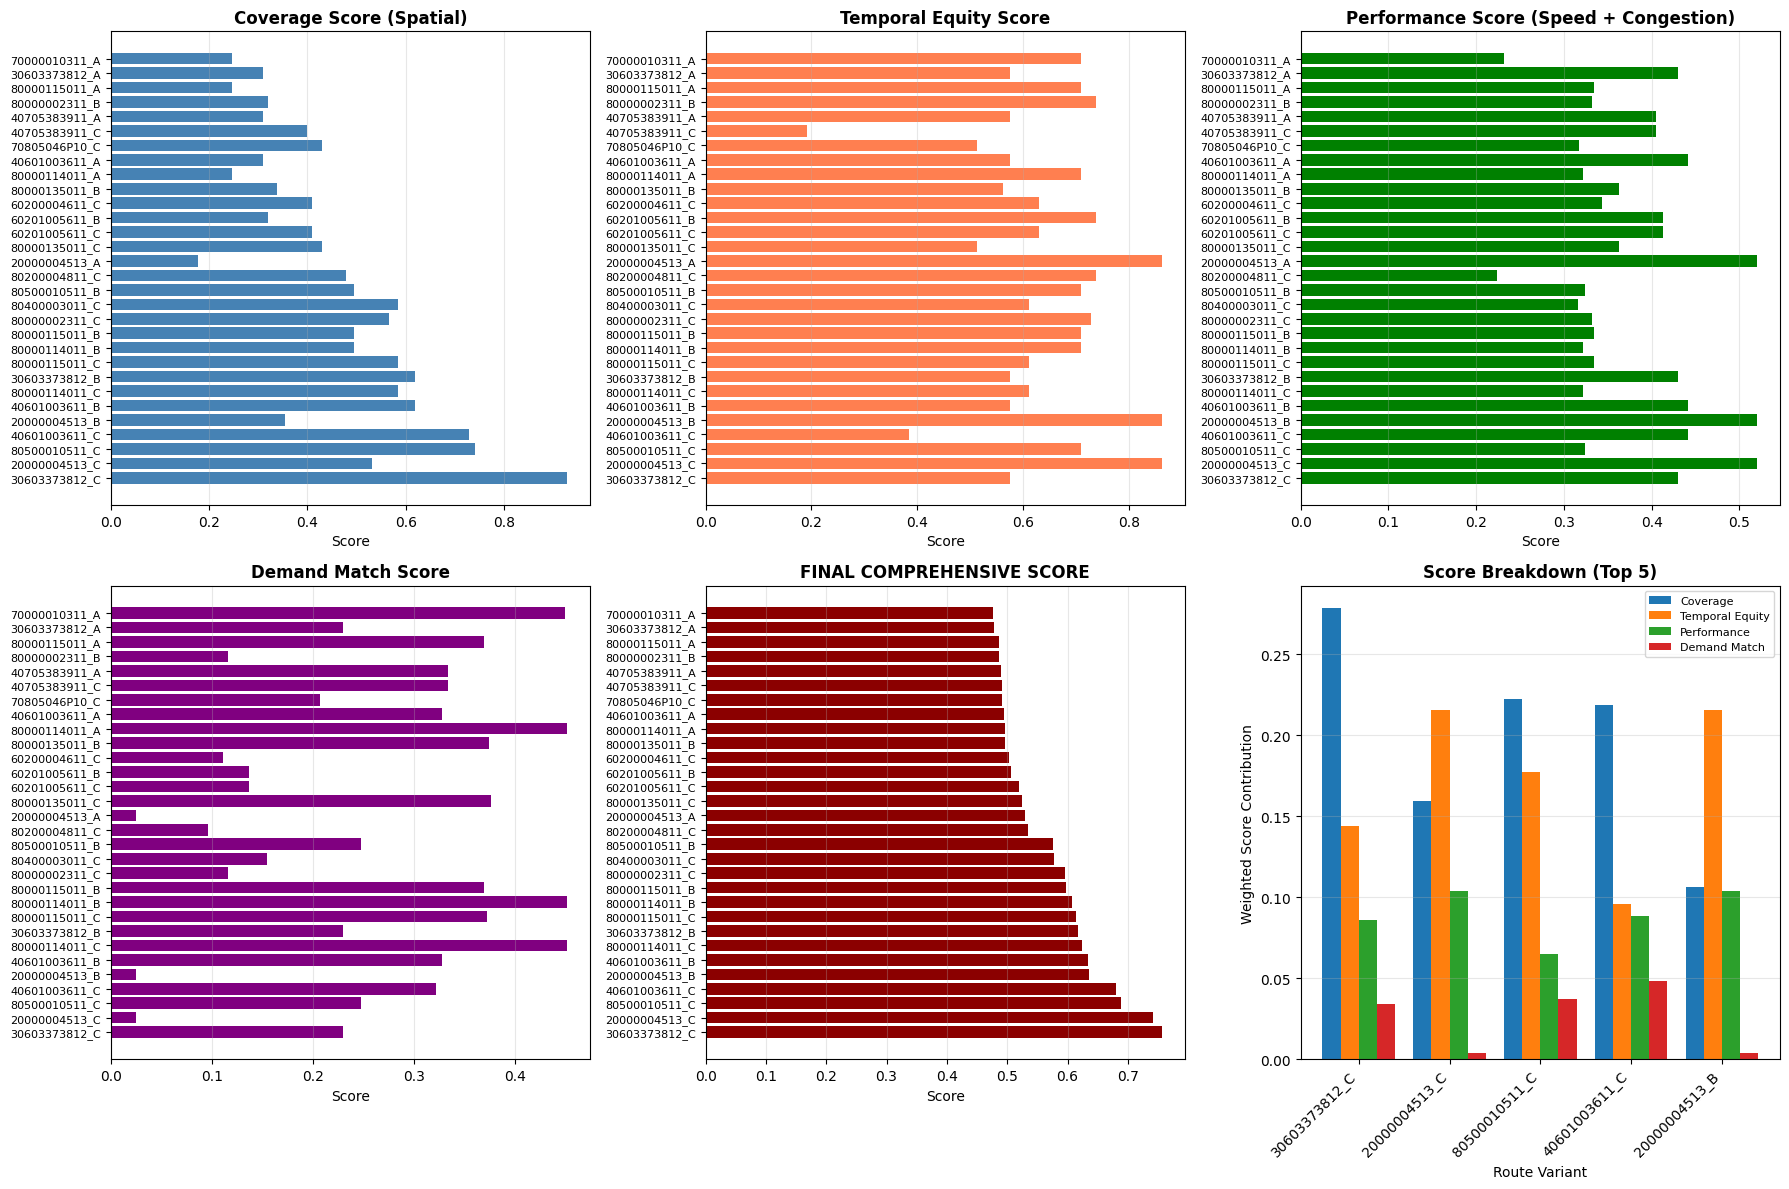

In [14]:
# Cell 8D: Component analysis visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

top_30 = variants_df.head(30)

# Coverage scores
ax = axes[0, 0]
ax.barh(range(len(top_30)), top_30['coverage_score'], color='steelblue')
ax.set_yticks(range(len(top_30)))
ax.set_yticklabels(top_30['variant_id'], fontsize=8)
ax.set_xlabel('Score')
ax.set_title('Coverage Score (Spatial)', fontweight='bold')
ax.grid(alpha=0.3, axis='x')

# Temporal equity
ax = axes[0, 1]
ax.barh(range(len(top_30)), top_30['temporal_equity_score'], color='coral')
ax.set_yticks(range(len(top_30)))
ax.set_yticklabels(top_30['variant_id'], fontsize=8)
ax.set_xlabel('Score')
ax.set_title('Temporal Equity Score', fontweight='bold')
ax.grid(alpha=0.3, axis='x')

# Performance
ax = axes[0, 2]
ax.barh(range(len(top_30)), top_30['performance_score'], color='green')
ax.set_yticks(range(len(top_30)))
ax.set_yticklabels(top_30['variant_id'], fontsize=8)
ax.set_xlabel('Score')
ax.set_title('Performance Score (Speed + Congestion)', fontweight='bold')
ax.grid(alpha=0.3, axis='x')

# Demand match
ax = axes[1, 0]
ax.barh(range(len(top_30)), top_30['demand_match_score'], color='purple')
ax.set_yticks(range(len(top_30)))
ax.set_yticklabels(top_30['variant_id'], fontsize=8)
ax.set_xlabel('Score')
ax.set_title('Demand Match Score', fontweight='bold')
ax.grid(alpha=0.3, axis='x')

# Final score
ax = axes[1, 1]
ax.barh(range(len(top_30)), top_30['final_score'], color='darkred')
ax.set_yticks(range(len(top_30)))
ax.set_yticklabels(top_30['variant_id'], fontsize=8)
ax.set_xlabel('Score')
ax.set_title('FINAL COMPREHENSIVE SCORE', fontweight='bold', fontsize=12)
ax.grid(alpha=0.3, axis='x')

# Score components breakdown for top 5
ax = axes[1, 2]
top_5 = variants_df.head(5)
components = ['coverage_score', 'temporal_equity_score', 'performance_score', 'demand_match_score']
weights = [0.30, 0.25, 0.20, 0.15]

x = np.arange(len(top_5))
width = 0.2

for i, (comp, weight) in enumerate(zip(components, weights)):
    values = top_5[comp] * weight
    ax.bar(x + i*width, values, width, label=comp.replace('_score', '').replace('_', ' ').title())

ax.set_xlabel('Route Variant')
ax.set_ylabel('Weighted Score Contribution')
ax.set_title('Score Breakdown (Top 5)', fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(top_5['variant_id'], rotation=45, ha='right')
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('comprehensive_scoring_analysis.png', dpi=300, bbox_inches='tight')
print("\nSaved comprehensive scoring analysis")
plt.show()

In [15]:
# Cell 9: Rank variants and get recommendations
# Sort by final score
variants_df = variants_df.sort_values('final_score', ascending=False)

print("="*70)
print("TOP 20 ROUTE RECOMMENDATIONS")
print("="*70)

top_20 = variants_df.head(20)

for idx, row in top_20.iterrows():
    print(f"\n{idx+1}. {row['variant_id']}")
    print(f"   New stops: {len(row['new_stops'])}")
    print(f"   Population served: {row['total_pop_served']:,.0f}")
    print(f"   Equity multiplier: {row['equity_multiplier']:.2f}x")
    print(f"   Final score: {row['final_score']:.3f}")
    print(f"   Stops: {row['new_stops']}")

# Save recommendations
variants_df.to_csv('route_recommendations.csv', index=False)
print(f"\n✅ Saved {len(variants_df)} recommendations to route_recommendations.csv")

TOP 20 ROUTE RECOMMENDATIONS

83. 30603373812_C
   New stops: 3
   Population served: 139,173
   Equity multiplier: 1.50x
   Final score: 0.757
   Stops: ['CANDIDATE_Dandora Area Iii Ward_38', 'CANDIDATE_Dandora Area Iii Ward_37', 'CANDIDATE_Dandora Area Iii Ward_42']

30. 20000004513_C
   New stops: 3
   Population served: 79,743
   Equity multiplier: 2.00x
   Final score: 0.743
   Stops: ['CANDIDATE_Githurai Ward_5', 'CANDIDATE_Githurai Ward_14', 'CANDIDATE_Githurai Ward_49']

191. 80500010511_C
   New stops: 3
   Population served: 111,183
   Equity multiplier: 1.50x
   Final score: 0.688
   Stops: ['CANDIDATE_Kangemi Ward_43', 'CANDIDATE_Kangemi Ward_8', 'CANDIDATE_Kangemi Ward_0']

102. 40601003611_C
   New stops: 3
   Population served: 109,239
   Equity multiplier: 1.67x
   Final score: 0.680
   Stops: ['CANDIDATE_Dandora Area Iii Ward_23', 'CANDIDATE_Dandora Area Iii Ward_17', 'CANDIDATE_Airbase Ward_23']

29. 20000004513_B
   New stops: 2
   Population served: 53,162
   Equity


✅ Saved analysis to route_recommendations_analysis.png


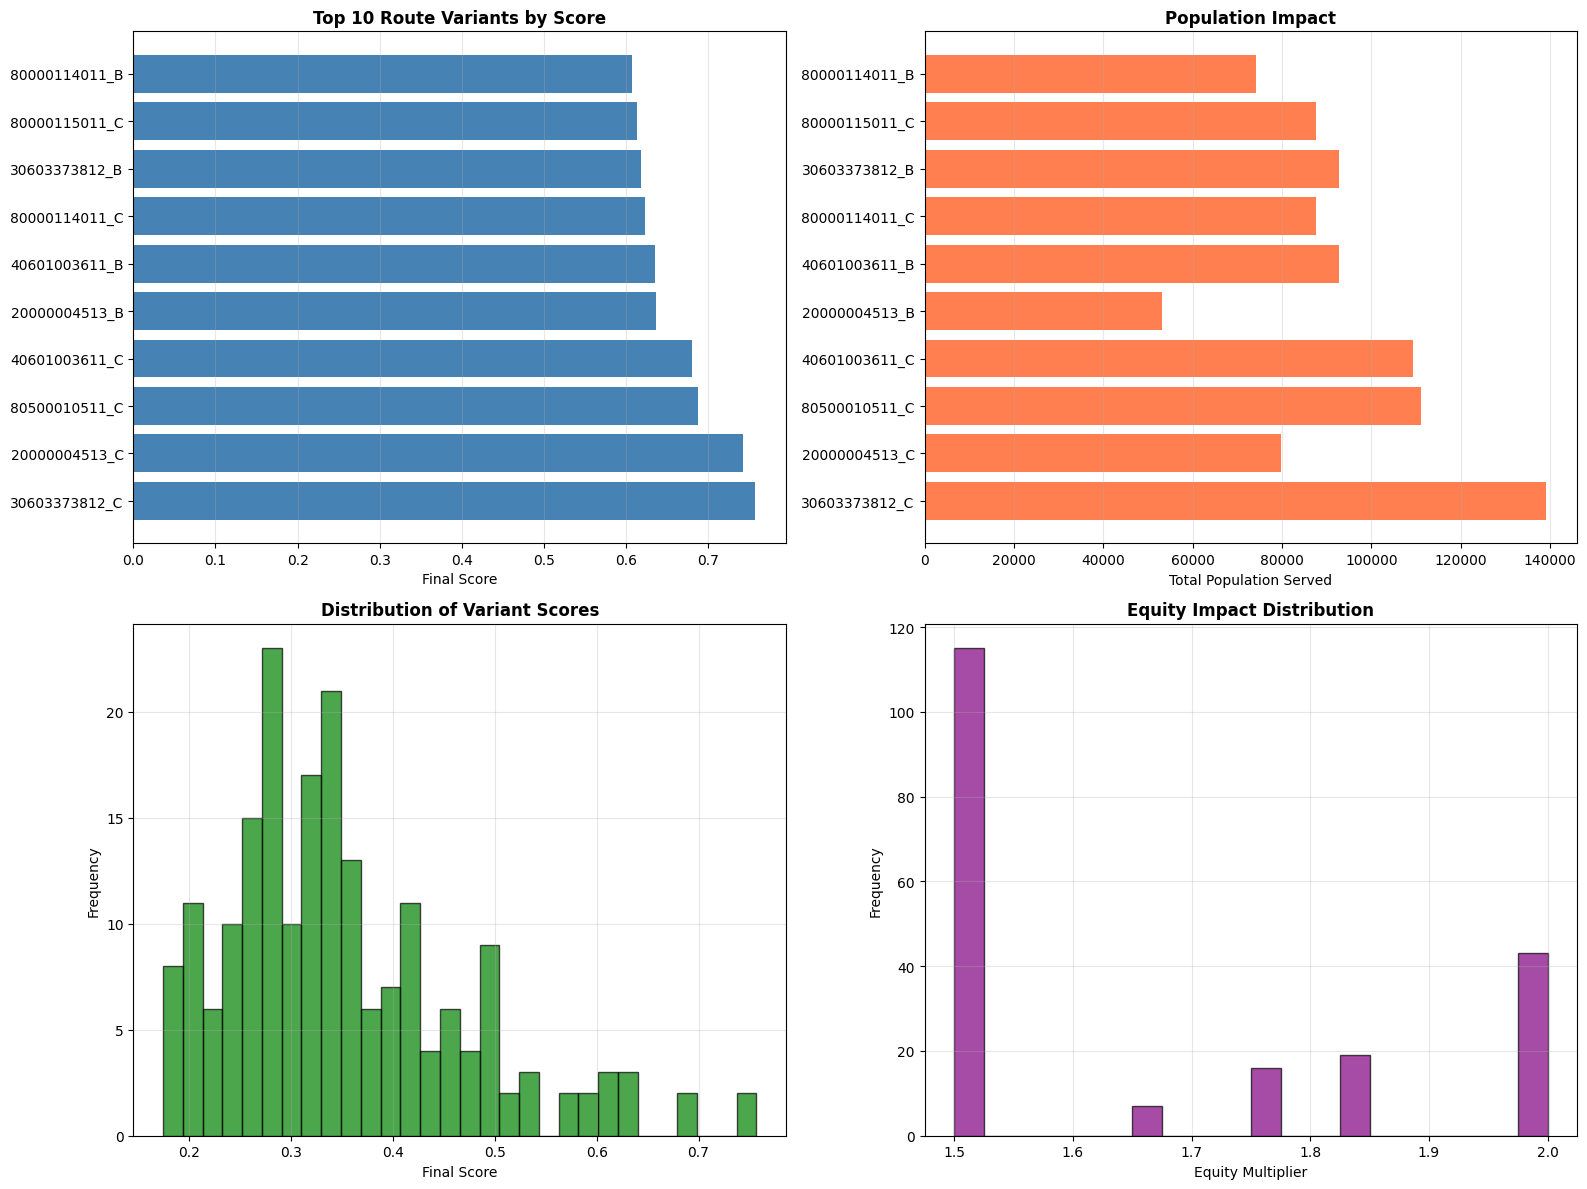

In [16]:
# Cell 10: Visualize top recommendations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top 10 by score
ax = axes[0, 0]
top_10 = variants_df.head(10)
ax.barh(range(len(top_10)), top_10['final_score'], color='steelblue')
ax.set_yticks(range(len(top_10)))
ax.set_yticklabels(top_10['variant_id'])
ax.set_xlabel('Final Score')
ax.set_title('Top 10 Route Variants by Score', fontweight='bold')
ax.grid(alpha=0.3, axis='x')

# Population served
ax = axes[0, 1]
ax.barh(range(len(top_10)), top_10['total_pop_served'], color='coral')
ax.set_yticks(range(len(top_10)))
ax.set_yticklabels(top_10['variant_id'])
ax.set_xlabel('Total Population Served')
ax.set_title('Population Impact', fontweight='bold')
ax.grid(alpha=0.3, axis='x')

# Score distribution
ax = axes[1, 0]
ax.hist(variants_df['final_score'], bins=30, edgecolor='black', alpha=0.7, color='green')
ax.set_xlabel('Final Score')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Variant Scores', fontweight='bold')
ax.grid(alpha=0.3)

# Equity multiplier distribution
ax = axes[1, 1]
ax.hist(variants_df['equity_multiplier'], bins=20, edgecolor='black', alpha=0.7, color='purple')
ax.set_xlabel('Equity Multiplier')
ax.set_ylabel('Frequency')
ax.set_title('Equity Impact Distribution', fontweight='bold')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('route_recommendations_analysis.png', dpi=300)
print("\n✅ Saved analysis to route_recommendations_analysis.png")
plt.show()

In [17]:
# Cell 11: Map visualization (optional - if you have folium)
try:
    import folium
    from folium import plugins
    
    # Create base map centered on Nairobi
    center_lat = selected_candidates['lat'].mean()
    center_lon = selected_candidates['lon'].mean()
    
    m = folium.Map(location=[center_lat, center_lon], zoom_start=12)
    
    # Add top 10 variants
    colors = ['red', 'blue', 'green', 'purple', 'orange', 'darkred', 'lightred', 'beige', 'darkblue', 'darkgreen']
    
    for i, (idx, variant) in enumerate(variants_df.head(10).iterrows()):
        color = colors[i % len(colors)]
        
        for coord in variant['new_stop_coords']:
            folium.CircleMarker(
                location=[coord[0], coord[1]],
                radius=8,
                popup=f"{variant['variant_id']}<br>Pop: {variant['total_pop_served']:,.0f}<br>Score: {variant['final_score']:.3f}",
                color=color,
                fill=True,
                fillColor=color,
                fillOpacity=0.7
            ).add_to(m)
    
    m.save('route_recommendations_map.html')
    print("Saved interactive map to route_recommendations_map.html")
    
except ImportError:
    print("⚠️  Folium not installed. Skipping map visualization.")
    print("   Install with: pip install folium")

Saved interactive map to route_recommendations_map.html


In [18]:
import folium
from folium import plugins

# Create base map centered on Nairobi
center_lat = selected_candidates['lat'].mean()
center_lon = selected_candidates['lon'].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=12,
    tiles="CartoDB positron"
)

# Add top 10 variants
colors = ['red', 'blue', 'green', 'purple', 'orange', 'darkred',
          'lightred', 'beige', 'darkblue', 'darkgreen']

for i, (idx, variant) in enumerate(variants_df.head(10).iterrows()):
    color = colors[i % len(colors)]
    
    for coord in variant['new_stop_coords']:
        folium.CircleMarker(
            location=[coord[0], coord[1]],
            radius=8,
            popup=(
                f"<b>{variant['variant_id']}</b><br>"
                f"Pop: {variant['total_pop_served']:,.0f}<br>"
                f"Score: {variant['final_score']:.3f}"
            ),
            color=color,
            fill=True,
            fillColor=color,
            fillOpacity=0.7
        ).add_to(m)

# Save and display
m.save('route_recommendations_map.html')
m


In [19]:
# Cell 12: Summary statistics by ward
print("="*70)
print("RECOMMENDATIONS BY WARD")
print("="*70)

# Get ward for each variant (from first new stop)
def get_variant_ward(variant):
    if len(variant['new_stops']) > 0:
        stop_id = variant['new_stops'][0]
        ward = selected_candidates[selected_candidates['stop_id'] == stop_id]['ward'].values
        return ward[0] if len(ward) > 0 else 'Unknown'
    return 'Unknown'

variants_df['ward'] = variants_df.apply(get_variant_ward, axis=1)

# Summary by ward
ward_summary = variants_df.groupby('ward').agg({
    'variant_id': 'count',
    'total_pop_served': 'sum',
    'final_score': 'mean',
    'equity_multiplier': 'mean'
}).rename(columns={'variant_id': 'num_variants'})

ward_summary = ward_summary.sort_values('final_score', ascending=False)

print(ward_summary)

# Save ward summary
ward_summary.to_csv('ward_summary.csv')
print(f"\n Saved ward summary to ward_summary.csv")

print("\n" + "="*70)
print("PHASE 2 COMPLETE!")
print("="*70)
print(f"\nGenerated:")
print(f"  • {len(variants_df)} route variants")
print(f"  • Covering {len(target_wards)} wards")
print(f"  • Total new population served: {variants_df['total_pop_served'].sum():,.0f}")
print(f"\nOutput files:")
print(f"  • route_recommendations.csv")
print(f"  • route_recommendations_analysis.png")
print(f"  • route_recommendations_map.html (if folium installed)")
print(f"  • ward_summary.csv")

RECOMMENDATIONS BY WARD
                       num_variants  total_pop_served  final_score  \
ward                                                                 
Githurai Ward                     3            159486     0.636202   
Dandora Area Iii Ward             9            686286     0.568836   
Kangemi Ward                     18           1073148     0.509567   
Gatina Ward                      14            605023     0.469468   
Mountain View Ward                6            233772     0.421796   
Imara Daima Ward                  5            102827     0.348031   
Airbase Ward                     56           1641075     0.330273   
Ngando Ward                       9            189892     0.290742   
Pipeline Ward                    24            497443     0.287472   
Nairobi West Ward                17            287727     0.275281   
Upper Savanna Ward               11            262582     0.271944   
Roysambu Ward                    27            548694     0.265153

In [ ]:
# Cell: Interactive Route Variant Visualizer
import folium
from folium import plugins

def visualize_route_variants(route_id, variants_df, route_geometries, 
                            selected_candidates, feed, save_path=None):
    """
    Visualize a route with all its variants
    
    Colors:
    - Green: Top recommended variant (highest score)
    - Red: Original route
    - Orange/Yellow/Purple: Other variants
    - Blue circles: Existing stops
    - Green stars: New stops (recommended)
    - Gray stars: New stops (other variants)
    """
    
    # Get variants for this route
    route_variants = variants_df[variants_df['route_id'] == route_id].copy()
    
    if len(route_variants) == 0:
        print(f"No variants found for route {route_id}")
        return None
    
    # Sort by score to get top recommendation
    route_variants = route_variants.sort_values('final_score', ascending=False)
    top_variant = route_variants.iloc[0]
    
    # Get original route stops
    original_stops = route_geometries[route_id]
    
    # Calculate center
    all_lats = list(original_stops['stop_lat'])
    all_lons = list(original_stops['stop_lon'])
    
    # Add candidate stop coords
    for _, variant in route_variants.iterrows():
        for coord in variant['new_stop_coords']:
            all_lats.append(coord[0])
            all_lons.append(coord[1])
    
    center_lat = np.mean(all_lats)
    center_lon = np.mean(all_lons)
    
    # Create map
    m = folium.Map(
        location=[center_lat, center_lon],
        tiles='CartoDB Positron',
        zoom_start=13,
        min_zoom=11,
        max_zoom=18,
        scrollWheelZoom=True,
        dragging=True
    )
    
    # Bounds
    bounds = [
        [min(all_lats) - 0.005, min(all_lons) - 0.005],
        [max(all_lats) + 0.005, max(all_lons) + 0.005]
    ]
    m.fit_bounds(bounds)
    
    # === 1. ORIGINAL ROUTE (Red) ===
    original_coords = original_stops[['stop_lat', 'stop_lon']].values.tolist()
    folium.PolyLine(
        original_coords,
        color='red',
        weight=4,
        opacity=0.7,
        popup=f"<b>Original Route {route_id}</b>",
        tooltip="Original Route"
    ).add_to(m)
    
    # Original stops (blue circles)
    for _, stop in original_stops.iterrows():
        folium.CircleMarker(
            location=[stop['stop_lat'], stop['stop_lon']],
            radius=5,
            color='darkblue',
            fill=True,
            fillColor='lightblue',
            fillOpacity=0.8,
            weight=2,
            popup=f"<b>Existing Stop</b><br>Stop ID: {stop['stop_id']}",
            tooltip="Existing Stop"
        ).add_to(m)
    
    # === 2. TOP RECOMMENDED VARIANT (Green) ===
    # Draw route with new stops
    extended_coords = original_coords.copy()
    
    # Add new stops to route path (simplified - just append)
    for coord in top_variant['new_stop_coords']:
        extended_coords.append([coord[0], coord[1]])
    
    folium.PolyLine(
        extended_coords,
        color='green',
        weight=5,
        opacity=0.9,
        popup=f"<b>RECOMMENDED: {top_variant['variant_id']}</b><br>"
              f"Score: {top_variant['final_score']:.3f}<br>"
              f"Pop served: {top_variant['total_pop_served']:,.0f}<br>"
              f"New stops: {len(top_variant['new_stops'])}",
        tooltip=f"TOP RECOMMENDATION (Score: {top_variant['final_score']:.3f})"
    ).add_to(m)
    
    # New stops for top variant (green stars)
    for i, (stop_id, coord) in enumerate(zip(top_variant['new_stops'], top_variant['new_stop_coords'])):
        stop_info = selected_candidates[selected_candidates['stop_id'] == stop_id].iloc[0]
        
        folium.Marker(
            location=[coord[0], coord[1]],
            icon=folium.Icon(color='green', icon='star', prefix='fa'),
            popup=f"<b>NEW STOP (RECOMMENDED)</b><br>"
                  f"Stop ID: {stop_id}<br>"
                  f"Ward: {stop_info['ward']}<br>"
                  f"Quality: {stop_info['gnn_probability']:.3f}<br>"
                  f"Pop within 500m: {stop_info['pop_within_500m']:,.0f}",
            tooltip=f"★ Recommended New Stop {i+1}"
        ).add_to(m)
    
    # === 3. OTHER VARIANTS (Gray/Orange) ===
    other_colors = ['orange', 'purple', 'darkgreen', 'cadetblue']
    
    for idx, (_, variant) in enumerate(route_variants.iloc[1:].iterrows()):
        color = other_colors[idx % len(other_colors)]
        
        # Draw variant path
        variant_coords = original_coords.copy()
        for coord in variant['new_stop_coords']:
            variant_coords.append([coord[0], coord[1]])
        
        folium.PolyLine(
            variant_coords,
            color=color,
            weight=3,
            opacity=0.4,
            dash_array='5, 10',
            popup=f"<b>Alternative: {variant['variant_id']}</b><br>"
                  f"Score: {variant['final_score']:.3f}<br>"
                  f"Pop served: {variant['total_pop_served']:,.0f}",
            tooltip=f"Alternative {idx+2}"
        ).add_to(m)
        
        # New stops for other variants (gray markers)
        for stop_id, coord in zip(variant['new_stops'], variant['new_stop_coords']):
            folium.CircleMarker(
                location=[coord[0], coord[1]],
                radius=6,
                color='gray',
                fill=True,
                fillColor='lightgray',
                fillOpacity=0.6,
                weight=2,
                popup=f"<b>Alternative Stop</b><br>Stop ID: {stop_id}",
                tooltip="Alternative new stop"
            ).add_to(m)
    
    # === 4. ADD LEGEND ===
    legend_html = '''
    <div style="position: fixed; 
                bottom: 50px; right: 50px; width: 280px; height: auto; 
                background-color: white; z-index:9999; font-size:14px;
                border:2px solid grey; border-radius: 5px; padding: 10px">
    <p style="margin:0; padding:5px; background-color:#f0f0f0; font-weight:bold; text-align:center;">
        Route Variants Legend
    </p>
    <p style="margin:5px 0;"><span style="color:red; font-size:20px;">━━━</span> Original Route</p>
    <p style="margin:5px 0;"><span style="color:green; font-size:20px; font-weight:bold;">━━━</span> 
       <b>RECOMMENDED Variant</b></p>
    <p style="margin:5px 0;"><span style="color:orange; font-size:20px;">┅┅┅</span> Alternative Variants</p>
    <p style="margin:5px 0;"><span style="color:lightblue; font-size:20px;">●</span> Existing Stops</p>
    <p style="margin:5px 0;"><span style="color:green; font-size:20px;">★</span> New Stops (Recommended)</p>
    <p style="margin:5px 0;"><span style="color:gray; font-size:20px;">●</span> New Stops (Alternative)</p>
    </div>
    '''
    m.get_root().html.add_child(folium.Element(legend_html))
    
    # === 5. ADD SUMMARY INFO BOX ===
    # Get route info
    route_info = feed.routes[feed.routes['route_id'] == route_id].iloc[0]
    
    # Calculate original population served (sum of existing stops)
    original_pop = 0
    for stop_id in original_stops['stop_id']:
        stop_data = df[df['stop_id'] == stop_id]
        if len(stop_data) > 0:
            original_pop += stop_data.iloc[0].get('pop_within_500m', 0)
    
    new_pop = top_variant['total_pop_served']
    total_pop = original_pop + new_pop
    increase_pct = (new_pop / original_pop * 100) if original_pop > 0 else 0
    
    info_html = f'''
    <div style="position: fixed; 
                top: 80px; left: 50px; width: 320px; height: auto; 
                background-color: white; z-index:9999; font-size:13px;
                border:2px solid green; border-radius: 5px; padding: 15px;
                box-shadow: 3px 3px 10px rgba(0,0,0,0.3);">
    <h3 style="margin:0 0 10px 0; color:green; text-align:center; border-bottom:2px solid green; padding-bottom:5px;">
        Route {route_id} Summary
    </h3>
    <p style="margin:5px 0;"><b>Route Name:</b> {route_info.get('route_short_name', 'N/A')}</p>
    <p style="margin:5px 0;"><b>Original Stops:</b> {len(original_stops)}</p>
    <p style="margin:5px 0;"><b>New Stops (Recommended):</b> {len(top_variant['new_stops'])}</p>
    
    <hr style="margin:10px 0;">
    
    <p style="margin:5px 0;"><b>Population Impact:</b></p>
    <p style="margin:5px 0; padding-left:15px;">• Original: <b>{original_pop:,.0f}</b> people</p>
    <p style="margin:5px 0; padding-left:15px;">• New stops add: <b style="color:green;">+{new_pop:,.0f}</b></p>
    <p style="margin:5px 0; padding-left:15px;">• Total: <b>{total_pop:,.0f}</b> people</p>
    <p style="margin:5px 0; padding-left:15px;">• Increase: <b style="color:green;">+{increase_pct:.1f}%</b></p>
    
    <hr style="margin:10px 0;">
    
    <p style="margin:5px 0;"><b>Recommendation Score:</b> 
       <span style="font-size:16px; color:green; font-weight:bold;">{top_variant['final_score']:.3f}</span></p>
    <p style="margin:5px 0;"><b>Equity Multiplier:</b> {top_variant['equity_multiplier']:.2f}x</p>
    
    <hr style="margin:10px 0;">
    
    <p style="margin:5px 0; font-size:11px; color:gray;">
        Click markers for details<br>
        Green star = recommended new stops
    </p>
    </div>
    '''
    m.get_root().html.add_child(folium.Element(info_html))
    
    # Save if path provided
    if save_path:
        m.save(save_path)
        print(f"Saved map to {save_path}")
    
    return m

# Example usage:
print("="*70)
print("ROUTE VARIANT VISUALIZER")
print("="*70)

# Get available routes
available_routes = variants_df['route_id'].unique()
print(f"\nAvailable routes with variants: {len(available_routes)}")
print(f"Routes: {list(available_routes[:10])}")

# Visualize top route
if len(available_routes) > 0:
    top_route = variants_df.groupby('route_id')['final_score'].max().idxmax()
    print(f"\nVisualizing top-scoring route: {top_route}")
    
    m = visualize_route_variants(
        route_id=top_route,
        variants_df=variants_df,
        route_geometries=route_geometries,
        selected_candidates=selected_candidates,
        feed=feed,
        save_path=f'route_{top_route}_variants.html'
    )
    
    print(f"\nInteractive map saved!")
    print(f" Open: route_{top_route}_variants.html")
    
    # Display in notebook
    m

ROUTE VARIANT VISUALIZER

Available routes with variants: 74
Routes: ['30603373812', '20000004513', '80500010511', '40601003611', '80000114011', '80000115011', '80000002311', '80400003011', '80200004811', '80000135011']

Visualizing top-scoring route: 30603373812
Saved map to route_30603373812_variants.html

Interactive map saved!
   Open: route_30603373812_variants.html


In [ ]:
# Cell: Interactive Route Selector & Checker
def check_route_variants(route_id, variants_df):
    """Check if a route has variants and show summary"""
    route_variants = variants_df[variants_df['route_id'] == route_id]
    
    if len(route_variants) == 0:
        print(f"Route {route_id} has NO variants")
        print(f"   This route does not pass through selected wards or has no nearby candidates")
        return None
    
    print(f"Route {route_id} has {len(route_variants)} variant(s)")
    print("="*70)
    
    for idx, variant in route_variants.iterrows():
        print(f"\n{variant['variant_id']}:")
        print(f"  New stops: {len(variant['new_stops'])}")
        print(f"  Population added: {variant['total_pop_served']:,.0f}")
        print(f"  Score: {variant['final_score']:.3f}")
        print(f"  Equity multiplier: {variant['equity_multiplier']:.2f}x")
    
    return route_variants

# List all routes with variants
print("="*70)
print("ROUTES WITH VARIANTS")
print("="*70)

routes_with_variants = variants_df.groupby('route_id').agg({
    'variant_id': 'count',
    'final_score': 'max',
    'total_pop_served': 'sum'
}).rename(columns={'variant_id': 'num_variants'}).sort_values('final_score', ascending=False)

print(f"\nFound {len(routes_with_variants)} routes with variants:\n")
print(routes_with_variants.head(20))

# Interactive selector
print("\n" + "="*70)
print("SELECT A ROUTE TO VISUALIZE")
print("="*70)

route_to_viz = input("\nEnter route_id (or press Enter for top-scored route): ").strip()

if not route_to_viz:
    route_to_viz = routes_with_variants.index[0]
    print(f"Using top-scored route: {route_to_viz}")

# Check and visualize
route_vars = check_route_variants(route_to_viz, variants_df)

if route_vars is not None:
    print(f"\nGenerating visualization...")
    # Will call visualization function next

ROUTES WITH VARIANTS

Found 74 routes with variants:

             num_variants  final_score  total_pop_served
route_id                                                
30603373812             3     0.756911            278346
20000004513             3     0.742526            159486
80500010511             3     0.687871            222366
40601003611             3     0.679880            248412
80000114011             3     0.623191            198926
80000115011             3     0.613658            198926
80000002311             3     0.595679            156631
80400003011             3     0.577534            175486
80200004811             3     0.534067            143484
80000135011             3     0.525196            128606
60201005611             3     0.520256            133191
60200004611             3     0.502536            122898
70805046P10             3     0.490732            105166
40705383911             3     0.490566            159528
70000010311             3     0.47

In [ ]:
# Cell: Improved Route Visualizer with Road Routing
import folium
from folium import plugins
import osmnx as ox

# Professional color palette
COLORS = {
    'original': '#E74C3C',        # Red
    'recommended': '#27AE60',     # Green
    'alternative_1': '#F39C12',   # Orange
    'alternative_2': '#9B59B6',   # Purple
    'alternative_3': '#3498DB',   # Blue
    'existing_stop': '#2C3E50',   # Dark gray
    'new_stop_rec': '#27AE60',    # Green
    'new_stop_alt': '#95A5A6'     # Light gray
}

def get_road_path_between_stops(G, lat1, lon1, lat2, lon2):
    """Get actual road path between two points using OSMnx"""
    try:
        # Find nearest nodes
        orig_node = ox.distance.nearest_nodes(G, lon1, lat1)
        dest_node = ox.distance.nearest_nodes(G, lon2, lat2)
        
        # Get shortest path
        route = ox.shortest_path(G, orig_node, dest_node, weight='length')
        
        if route:
            # Convert to coordinates
            path_coords = [(G.nodes[node]['y'], G.nodes[node]['x']) for node in route]
            return path_coords
        else:
            return [[lat1, lon1], [lat2, lon2]]  # Fallback to straight line
    except:
        return [[lat1, lon1], [lat2, lon2]]  # Fallback

def visualize_route_variants_improved(route_id, variants_df, route_geometries, 
                                     selected_candidates, feed, G, save_path=None):
    """
    Enhanced route visualizer with actual road routing and professional colors
    """
    
    # Check if route has variants
    route_variants = variants_df[variants_df['route_id'] == route_id].copy()
    
    if len(route_variants) == 0:
        print(f"Route {route_id} has no variants")
        return None
    
    route_variants = route_variants.sort_values('final_score', ascending=False)
    top_variant = route_variants.iloc[0]
    
    # Get original route
    original_stops = route_geometries[route_id]
    
    # Calculate bounds
    all_lats = list(original_stops['stop_lat'])
    all_lons = list(original_stops['stop_lon'])
    
    for _, variant in route_variants.iterrows():
        for coord in variant['new_stop_coords']:
            all_lats.append(coord[0])
            all_lons.append(coord[1])
    
    center_lat = np.mean(all_lats)
    center_lon = np.mean(all_lons)
    
    # Create map with better styling
    m = folium.Map(
        location=[center_lat, center_lon],
        tiles='https://{s}.basemaps.cartocdn.com/light_all/{z}/{x}/{y}{r}.png',
        attr='&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors &copy; <a href="https://carto.com/attributions">CARTO</a>',
        zoom_start=13,
        scrollWheelZoom=True,
        dragging=True
    )
    
    # Add Google Maps-like terrain option
    folium.TileLayer(
        tiles='https://mt1.google.com/vt/lyrs=m&x={x}&y={y}&z={z}',
        attr='Google',
        name='Google Maps',
        overlay=False,
        control=True
    ).add_to(m)
    
    # Bounds
    bounds = [
        [min(all_lats) - 0.005, min(all_lons) - 0.005],
        [max(all_lats) + 0.005, max(all_lons) + 0.005]
    ]
    m.fit_bounds(bounds)
    
    # === 1. ORIGINAL ROUTE with road routing ===
    print("Drawing original route with road paths...")
    original_path = []
    
    for i in range(len(original_stops) - 1):
        lat1, lon1 = original_stops.iloc[i][['stop_lat', 'stop_lon']]
        lat2, lon2 = original_stops.iloc[i+1][['stop_lat', 'stop_lon']]
        
        segment = get_road_path_between_stops(G, lat1, lon1, lat2, lon2)
        original_path.extend(segment)
    
    folium.PolyLine(
        original_path,
        color=COLORS['original'],
        weight=5,
        opacity=0.8,
        popup=f"<b>Original Route {route_id}</b>",
        tooltip="Current Route"
    ).add_to(m)
    
    # Original stops
    for _, stop in original_stops.iterrows():
        folium.CircleMarker(
            location=[stop['stop_lat'], stop['stop_lon']],
            radius=6,
            color=COLORS['existing_stop'],
            fill=True,
            fillColor='white',
            fillOpacity=1,
            weight=2,
            popup=f"<b>Existing Stop</b><br>{stop['stop_id']}",
            tooltip="Existing Stop"
        ).add_to(m)
    
    # === 2. TOP RECOMMENDED VARIANT ===
    print("Drawing recommended variant...")
    recommended_path = original_path.copy()
    
    # Add segments to new stops
    last_stop = original_stops.iloc[-1]
    last_lat, last_lon = last_stop['stop_lat'], last_stop['stop_lon']
    
    for coord in top_variant['new_stop_coords']:
        segment = get_road_path_between_stops(G, last_lat, last_lon, coord[0], coord[1])
        recommended_path.extend(segment)
        last_lat, last_lon = coord[0], coord[1]
    
    folium.PolyLine(
        recommended_path,
        color=COLORS['recommended'],
        weight=6,
        opacity=0.95,
        popup=f"<b>RECOMMENDED: {top_variant['variant_id']}</b><br>"
              f"Score: {top_variant['final_score']:.3f}<br>"
              f"Pop: +{top_variant['total_pop_served']:,.0f}<br>"
              f"New stops: {len(top_variant['new_stops'])}",
        tooltip=f"TOP CHOICE (Score: {top_variant['final_score']:.3f})"
    ).add_to(m)
    
    # New stops for recommended variant
    for i, (stop_id, coord) in enumerate(zip(top_variant['new_stops'], top_variant['new_stop_coords'])):
        stop_info = selected_candidates[selected_candidates['stop_id'] == stop_id].iloc[0]
        
        folium.Marker(
            location=[coord[0], coord[1]],
            icon=folium.Icon(
                color='green', 
                icon='plus-circle', 
                prefix='fa',
                icon_color='white'
            ),
            popup=f"<b>NEW STOP (RECOMMENDED)</b><br>"
                  f"ID: {stop_id}<br>"
                  f"Ward: {stop_info['ward']}<br>"
                  f"Quality: {stop_info['gnn_probability']:.2%}<br>"
                  f"Pop: {stop_info['pop_within_500m']:,.0f}",
            tooltip=f"New Stop #{i+1}"
        ).add_to(m)
    
    # === 3. OTHER VARIANTS ===
    alt_colors = [COLORS['alternative_1'], COLORS['alternative_2'], COLORS['alternative_3']]
    
    for idx, (_, variant) in enumerate(route_variants.iloc[1:].iterrows()):
        if idx >= len(alt_colors):
            break
            
        color = alt_colors[idx]
        
        # Build path with road routing
        alt_path = original_path.copy()
        last_lat, last_lon = original_stops.iloc[-1][['stop_lat', 'stop_lon']]
        
        for coord in variant['new_stop_coords']:
            segment = get_road_path_between_stops(G, last_lat, last_lon, coord[0], coord[1])
            alt_path.extend(segment)
            last_lat, last_lon = coord[0], coord[1]
        
        folium.PolyLine(
            alt_path,
            color=color,
            weight=4,
            opacity=0.5,
            dash_array='8, 12',
            popup=f"<b>Alternative: {variant['variant_id']}</b><br>"
                  f"Score: {variant['final_score']:.3f}<br>"
                  f"Pop: +{variant['total_pop_served']:,.0f}",
            tooltip=f"Alternative #{idx+2}"
        ).add_to(m)
        
        # New stops for alternatives
        for stop_id, coord in zip(variant['new_stops'], variant['new_stop_coords']):
            folium.CircleMarker(
                location=[coord[0], coord[1]],
                radius=7,
                color=COLORS['new_stop_alt'],
                fill=True,
                fillColor=color,
                fillOpacity=0.7,
                weight=2,
                popup=f"<b>Alternative Stop</b><br>{stop_id}",
                tooltip="Alternative"
            ).add_to(m)
    
    # === 4. PROFESSIONAL LEGEND ===
    legend_html = f'''
    <div style="position: fixed; 
                bottom: 50px; right: 50px; width: 300px;
                background: white; z-index:9999; font-size:13px;
                border-radius: 8px; box-shadow: 0 4px 6px rgba(0,0,0,0.1);
                padding: 15px; font-family: 'Segoe UI', Arial, sans-serif;">
    <div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
                color: white; padding: 10px; margin: -15px -15px 15px -15px;
                border-radius: 8px 8px 0 0; font-weight: bold; text-align: center;">
        Route Variants Legend
    </div>
    <p style="margin:8px 0;"><span style="color:{COLORS['original']}; font-size:20px; font-weight:bold;">━━━</span> Current Route</p>
    <p style="margin:8px 0;"><span style="color:{COLORS['recommended']}; font-size:22px; font-weight:bold;">━━━</span> 
       <b>RECOMMENDED</b></p>
    <p style="margin:8px 0;"><span style="color:{COLORS['alternative_1']}; font-size:18px;">┅┅┅</span> Alternative Options</p>
    <hr style="margin:12px 0; border:0; border-top:1px solid #ddd;">
    <p style="margin:8px 0;"><span style="color:{COLORS['existing_stop']}; font-size:18px;">⬤</span> Existing Stops</p>
    <p style="margin:8px 0;"><span style="color:{COLORS['recommended']}; font-size:18px;">✚</span> New Stops (Rec.)</p>
    <p style="margin:8px 0;"><span style="color:{COLORS['new_stop_alt']}; font-size:18px;">⬤</span> New Stops (Alt.)</p>
    </div>
    '''
    m.get_root().html.add_child(folium.Element(legend_html))
    
    # === 5. SUMMARY CARD ===
    route_info = feed.routes[feed.routes['route_id'] == route_id].iloc[0]
    
    original_pop = 0
    for stop_id in original_stops['stop_id']:
        stop_data = df[df['stop_id'] == stop_id]
        if len(stop_data) > 0:
            original_pop += stop_data.iloc[0].get('pop_within_500m', 0)
    
    new_pop = top_variant['total_pop_served']
    increase_pct = (new_pop / original_pop * 100) if original_pop > 0 else 0
    
    info_html = f'''
    <div style="position: fixed; 
                top: 80px; left: 50px; width: 340px;
                background: white; z-index:9999; font-size:13px;
                border-radius: 10px; box-shadow: 0 6px 12px rgba(0,0,0,0.15);
                padding: 0; font-family: 'Segoe UI', Arial, sans-serif;">
    <div style="background: linear-gradient(135deg, {COLORS['recommended']} 0%, #229954 100%);
                color: white; padding: 15px; border-radius: 10px 10px 0 0;">
        <h3 style="margin:0; text-align:center; font-size:18px;">
            Route {route_id}
        </h3>
        <p style="margin:5px 0 0 0; text-align:center; font-size:12px; opacity:0.9;">
            {route_info.get('route_short_name', 'N/A')}
        </p>
    </div>
    <div style="padding:15px;">
        <div style="display:flex; justify-content:space-between; margin:8px 0;">
            <span>Original Stops:</span>
            <b>{len(original_stops)}</b>
        </div>
        <div style="display:flex; justify-content:space-between; margin:8px 0;">
            <span>New Stops:</span>
            <b style="color:{COLORS['recommended']}">{len(top_variant['new_stops'])}</b>
        </div>
        
        <hr style="margin:12px 0; border:0; border-top:2px solid #eee;">
        
        <div style="background:#f8f9fa; padding:10px; border-radius:5px; margin:10px 0;">
            <p style="margin:0 0 8px 0; font-weight:bold; color:#555;">📊 Population Impact</p>
            <div style="display:flex; justify-content:space-between; margin:5px 0; font-size:12px;">
                <span>Current:</span>
                <span>{original_pop:,.0f} people</span>
            </div>
            <div style="display:flex; justify-content:space-between; margin:5px 0; font-size:12px;">
                <span style="color:{COLORS['recommended']}">New stops:</span>
                <b style="color:{COLORS['recommended']}">+{new_pop:,.0f}</b>
            </div>
            <div style="display:flex; justify-content:space-between; margin:8px 0 0 0; padding-top:8px; border-top:1px solid #ddd;">
                <span><b>Total:</b></span>
                <b style="font-size:16px;">{original_pop + new_pop:,.0f}</b>
            </div>
            <div style="text-align:center; margin-top:8px; padding:6px; background:{COLORS['recommended']}; color:white; border-radius:4px; font-weight:bold;">
                +{increase_pct:.1f}% Increase
            </div>
        </div>
        
        <div style="display:flex; justify-content:space-between; margin:12px 0 8px 0;">
            <span>Score:</span>
            <b style="color:{COLORS['recommended']}; font-size:16px;">{top_variant['final_score']:.3f}</b>
        </div>
        <div style="display:flex; justify-content:space-between; margin:8px 0;">
            <span>Equity Boost:</span>
            <b>{top_variant['equity_multiplier']:.2f}×</b>
        </div>
    </div>
    </div>
    '''
    m.get_root().html.add_child(folium.Element(info_html))
    
    # Add layer control
    folium.LayerControl().add_to(m)
    
    if save_path:
        m.save(save_path)
        print(f"Saved to {save_path}")
    
    return m

# Usage
print("\nGenerating improved visualization...")
m = visualize_route_variants_improved(
    route_id=route_to_viz,
    variants_df=variants_df,
    route_geometries=route_geometries,
    selected_candidates=selected_candidates,
    feed=feed,
    G=G,
    save_path=f'route_{route_to_viz}_professional.html'
)

if m:
    print(" Done! Open the HTML file to view")
    m


🎨 Generating improved visualization...
Drawing original route with road paths...
Drawing recommended variant...
✅ Saved to route_30603373812_professional.html
✅ Done! Open the HTML file to view
